In [15]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)



In [16]:
df = df[df['job_title_short']== 'Data Analyst']
df_exploded = df.explode('job_skills')
df_exploded[['job_title_short', 'job_skills', 'salary_year_avg']].dropna()

,job_title_short,job_skills,salary_year_avg
109,Data Analyst,python,89000.0
109,Data Analyst,r,89000.0
109,Data Analyst,alteryx,89000.0
109,Data Analyst,tableau,89000.0
180,Data Analyst,excel,90250.0
...,...,...,...
784882,Data Analyst,alteryx,87500.0
785187,Data Analyst,sql,111175.0
785187,Data Analyst,python,111175.0
785187,Data Analyst,r,111175.0


In [17]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)
lists= skill_stats.index 

skill_count = 20
skill_stats = skill_stats.sort_values(by = 'skill_count', ascending = False).head(skill_count)

skill_stats


,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


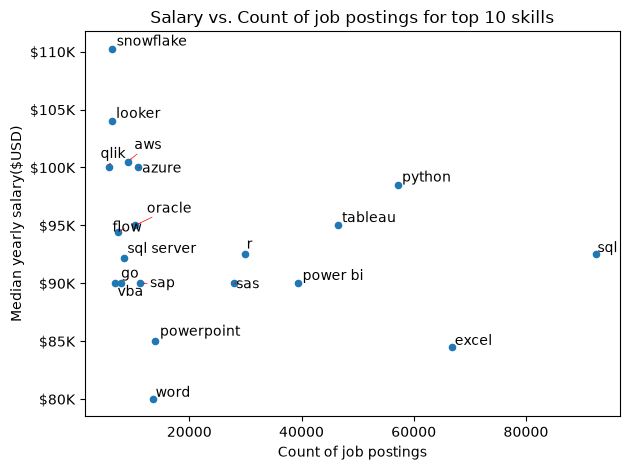

In [ ]:
fig, ax = plt.subplots()

lists= skill_stats.index
skill_stats.plot(kind = 'scatter', x = 'skill_count', y ='median_salary', ax = ax)
plt.xlabel('Count of job postings')
plt.ylabel('Median yearly salary($USD)')
plt.title('Salary vs. Count of job postings for top 10 skills')
texts = []

for txt in skill_stats.index:
    text = plt.text(skill_stats.loc[txt,'skill_count'], skill_stats.loc[txt,'median_salary'], txt) #x, y, text displayed at that coordinate
    texts.append(text)
adjust_text(texts, arrowprops = dict(arrowstyle = '->', color = 'r', lw = 0.5))
 
ax =plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos : f'${int(y/1000)}K'))
plt.tight_layout()